# Data Visualization

In [26]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [27]:
#libraries required for the implementation
import random, math, cv2
import glob as ld_f_dr
import random as rdm
import sympy as sd
import sys as open
import numpy as sc_p_op
import matplotlib.pyplot as pl_view
sc_p_op.random.seed(0)
import tensorflow as bckend_mdl
from tensorflow import keras as kr


grass= ld_f_dr.glob('/content/drive/MyDrive/rsscn7/aGrass/*.*')
field= ld_f_dr.glob('/content/drive/MyDrive/rsscn7/bField/*.*')
industry= ld_f_dr.glob('/content/drive/MyDrive/rsscn7/cIndustry/*.*')
riverlake= ld_f_dr.glob('/content/drive/MyDrive/rsscn7/dRiverLake/*.*')
forest= ld_f_dr.glob('/content/drive/MyDrive/rsscn7/eForest/*.*')
resident= ld_f_dr.glob('/content/drive/MyDrive/rsscn7/fResident/*.*')
parking= ld_f_dr.glob('/content/drive/MyDrive/rsscn7/gParking/*.*')
rsscn_data = []
rsscn_label = []


for i in grass:
    satellite=bckend_mdl.keras.preprocessing.image.load_img(i, color_mode='rgb', target_size= (64,64,3))
    satellite=sc_p_op.array(satellite)
    rsscn_data.append(satellite)
    rsscn_label.append(0)
for i in field:
    satellite=bckend_mdl.keras.preprocessing.image.load_img(i, color_mode='rgb',target_size= (64, 64,3))
    satellite=sc_p_op.array(satellite)
    rsscn_data.append(satellite)
    rsscn_label.append(1)
for i in industry:
    satellite=bckend_mdl.keras.preprocessing.image.load_img(i, color_mode='rgb', target_size= (64, 64,3))
    satellite=sc_p_op.array(satellite)
    rsscn_data.append(satellite)
    rsscn_label.append(2)
for i in riverlake:
    satellite=bckend_mdl.keras.preprocessing.image.load_img(i, color_mode='rgb',target_size= (64, 64,3))
    satellite=sc_p_op.array(satellite)
    rsscn_data.append(satellite)
    rsscn_label.append(3)
for i in forest:
    satellite=bckend_mdl.keras.preprocessing.image.load_img(i, color_mode='rgb', target_size= (64, 64,3))
    satellite=sc_p_op.array(satellite)
    rsscn_data.append(satellite)
    rsscn_label.append(4)
for i in resident:
    satellite=bckend_mdl.keras.preprocessing.image.load_img(i, color_mode='rgb',target_size= (64,64,3))
    satellite=sc_p_op.array(satellite)
    rsscn_data.append(satellite)
    rsscn_label.append(5)
for i in parking:
    satellite=bckend_mdl.keras.preprocessing.image.load_img(i, color_mode='rgb',target_size= (64, 64,3))
    satellite=sc_p_op.array(satellite)
    rsscn_data.append(satellite)
    rsscn_label.append(6)

In [28]:
rsscn_data=sc_p_op.array(rsscn_data)
rsscn_label=sc_p_op.array(rsscn_label)

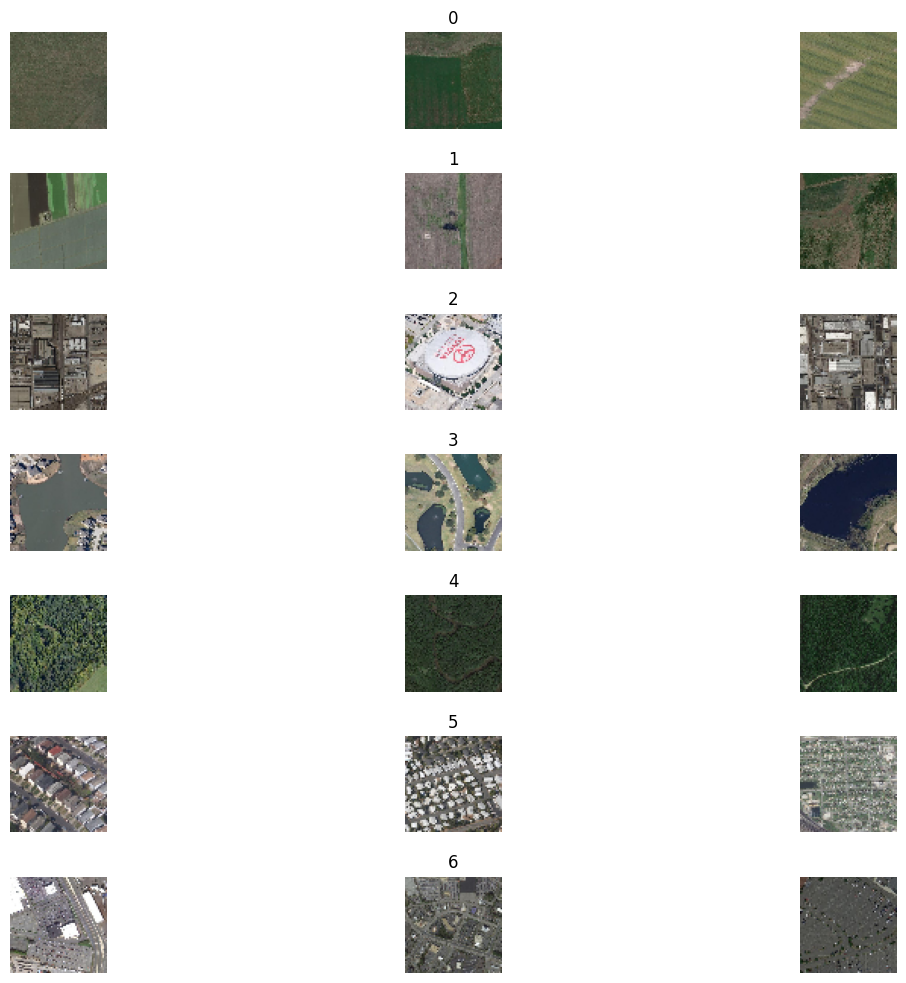

In [29]:
#class data distribution visualisation with the help of plotting technique
fg, img = pl_view.subplots(nrows=7, ncols=3, figsize=(12,10))
fg.tight_layout()

smp_sat_count=[]
for k in range(3):
  for n in range(7):
    x_rsscn = rsscn_data[rsscn_label == n]
    img[n][k].imshow(x_rsscn[random.randint(0,(len(x_rsscn) - 1)), :, :])
    img[n][k].axis("off")
    if k == 1:
      img[n][k].set_title(str(n))
      smp_sat_count.append(len(x_rsscn))

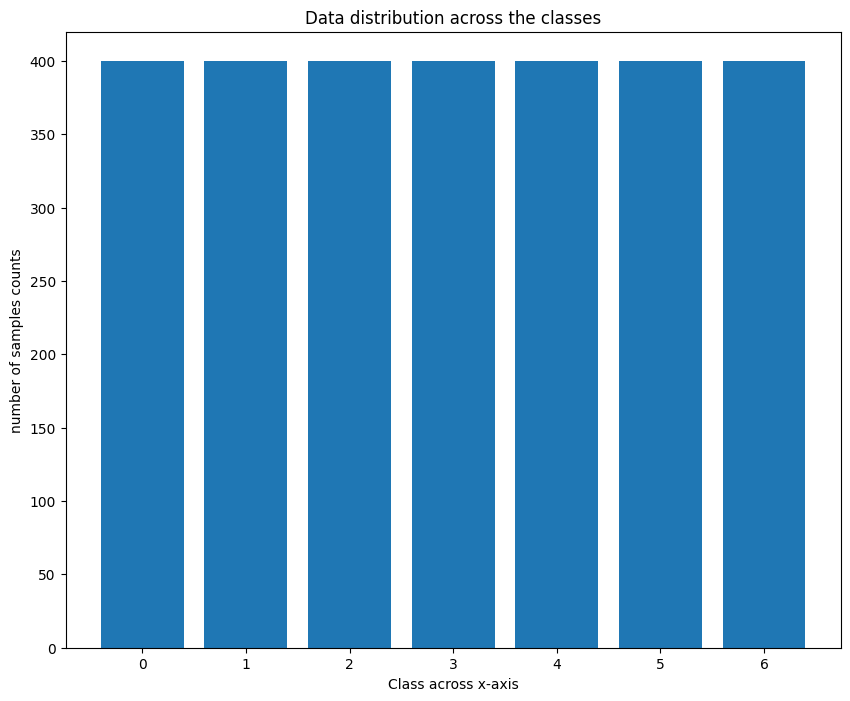

In [30]:
#class wise image count visualization with the help of bar plot technique
pl_view.figure(figsize=(10, 8))
pl_view.bar(range(0, 7), smp_sat_count)
pl_view.title("Data distribution across the classes")
pl_view.xlabel("Class across x-axis")
pl_view.ylabel("number of samples counts")
pl_view.show()

# CVT

In [31]:
pip install tensorflow-addons

In [32]:
from sklearn.model_selection import train_test_split as spl
rsscn_x=sc_p_op.array(rsscn_data)
rsscn_y=sc_p_op.array(rsscn_label)
x_rsscn,x_rsscn_tst, y_rsscn, y_rsscn_tst=spl(rsscn_x, rsscn_y, test_size=0.1,random_state=5)

In [33]:
dsct_rte = 0.001
dc_wt = 0.0001
bt_sz = 128
itr = 200
im_dim = 72
pt_dim = 6
n_ptc = (im_dim // pt_dim) ** 2
pr_dm = 64
nm_hs = 4
trfm_uns = [
    pr_dm * 2,
    pr_dm,
]
trfm_lys = 8
mlp_hd_uns = [2048, 1024]

In [34]:
ttl_cl=7
import numpy as np
import tensorflow as bckend
from tensorflow import keras
from tensorflow.keras import layers as l_y_s
import tensorflow_addons as g_d

In [35]:
img_ag = keras.Sequential(
    [
        l_y_s.Normalization(),
        l_y_s.Resizing(im_dim , im_dim),
        l_y_s.RandomFlip("horizontal"),
        l_y_s.RandomFlip("vertical"),
        l_y_s.RandomRotation(factor=0.02),
        l_y_s.RandomZoom(
            height_factor=0.2, width_factor=0.2
        ),
    ],
    name="img_ag",
)

img_ag.layers[0].adapt(x_rsscn)

In [36]:
def perc_mlt_lyr(rss, h_d_u, d_r):
    for k in h_d_u:
        rss = l_y_s.Dense(k, activation=bckend.nn.gelu)(rss)
        rss = l_y_s.Dropout(d_r)(rss)
    return rss

In [37]:
class token_with_patch(l_y_s.Layer):
    def __init__(self, pt_dim):
        super().__init__()
        self.pt_dim = pt_dim

    def call(self, im):
        bt_sz = bckend.shape(im)[0]
        ptch = bckend.image.extract_patches(
            images =im,
            sizes =[1, self.pt_dim, self.pt_dim, 1],
            strides =[1, self.pt_dim, self.pt_dim, 1],
            rates =[1, 1, 1, 1],
            padding ="VALID",
        )
        ptch_d = ptch.shape[-1]
        ptch = bckend.reshape(ptch, [bt_sz, -1, ptch_d])
        return ptch

Image_Dimension: 72 X 72
Patch_Dimension: 6 X 6
Patch_token_per_pic: 144
Pr_pch_pixels: 108


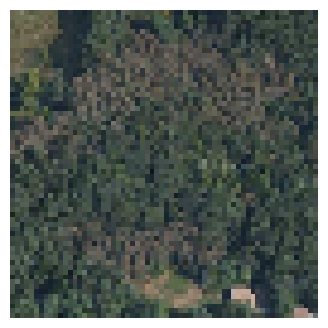

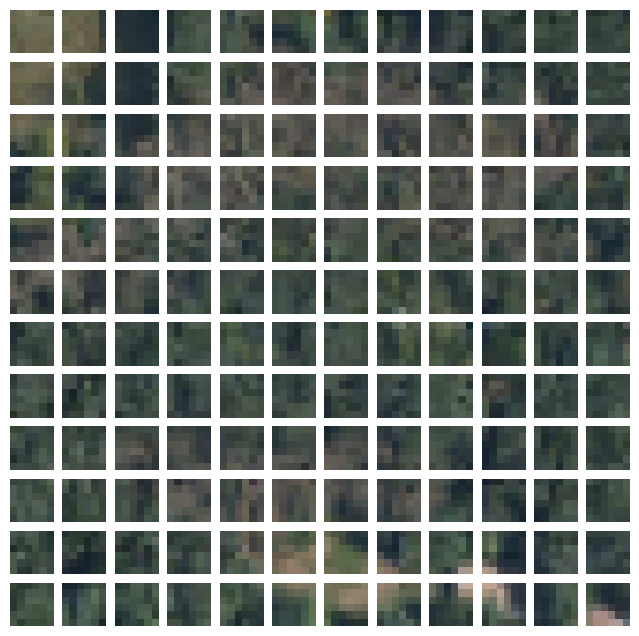

In [38]:
pl_view.figure(figsize=(4, 4))
pic = x_rsscn[np.random.choice(range(x_rsscn.shape[0]))]
pl_view.imshow(pic.astype("uint8"))
pl_view.axis("off")

r_im_dim = bckend.image.resize(
    bckend.convert_to_tensor([pic]), size=(im_dim , im_dim )
)
ptchs = token_with_patch(pt_dim )(r_im_dim)
print(f"Image_Dimension: {im_dim } X {im_dim }")
print(f"Patch_Dimension: {pt_dim } X {pt_dim }")
print(f"Patch_token_per_pic: {ptchs.shape[1]}")
print(f"Pr_pch_pixels: {ptchs.shape[-1]}")

k = int(np.sqrt(ptchs.shape[1]))
pl_view.figure(figsize=(8, 8))
for l, pt in enumerate(ptchs[0]):
    ax = pl_view.subplot(k, k, l + 1)
    ph_ig = bckend.reshape(pt, (pt_dim , pt_dim , 3))
    pl_view.imshow(ph_ig.numpy().astype("uint8"))
    pl_view.axis("off")

In [39]:
class enc_pat(l_y_s.Layer):
    def __init__(self, n_ptc , pr_dm):
        super().__init__()
        self.n_ptc  = n_ptc
        self.prj = l_y_s.Dense(pr_dm)
        self.pos_em = l_y_s.Embedding(
            input_dim=n_ptc , output_dim=pr_dm)

    def call(self, ptc):
        p_o_s = bckend.range(0,self.n_ptc,1)
        e_n_c = self.prj(ptc) + self.pos_em(p_o_s)
        return e_n_c

In [40]:
def cvt_mdl():
    i_n_p = l_y_s.Input(shape=i_n_s_h_p_e)

    agm = img_ag(i_n_p)

    ptch = token_with_patch(pt_dim)(agm)

    en_ptch = enc_pat(n_ptc,pr_dm)(ptch)

    for _ in range(trfm_lys):

        rsscn_1 = l_y_s.LayerNormalization(epsilon=1e-6)(en_ptch)

        atn_ot = l_y_s.MultiHeadAttention(
            num_heads=nm_hs, key_dim=pr_dm , dropout=0.1
        )(rsscn_1, rsscn_1)

        rsscn_2 = l_y_s.Add()([atn_ot, en_ptch])

        rsscn_3 = l_y_s.LayerNormalization(epsilon=1e-6)(rsscn_2)

        rsscn_3 = perc_mlt_lyr(rsscn_3, trfm_uns,0.1)

        en_ptch = l_y_s.Add()([rsscn_3, rsscn_2])


    rp_rss = l_y_s.LayerNormalization(epsilon=1e-6)(en_ptch)
    rp_rss = l_y_s.Flatten()(rp_rss)
    rp_rss = l_y_s.Dropout(0.5)(rp_rss)

    ft = perc_mlt_lyr(rp_rss, mlp_hd_uns, 0.5)

    f_o_u_t = l_y_s.Dense(ttl_cl)(ft)

    cvt = keras.Model(i_n_p, f_o_u_t)
    return cvt

In [41]:
i_n_s_h_p_e = (64, 64, 3)
def trn_cvt_mdl(cvt):
    g_d_o_p_t = g_d.optimizers.AdamW(
        learning_rate=dsct_rte, weight_decay=dc_wt
    )

    cvt.compile(
        optimizer=g_d_o_p_t,
        loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
        metrics=[
            keras.metrics.SparseCategoricalAccuracy(name="accuracy"),
            keras.metrics.SparseTopKCategoricalAccuracy(5, name="top-5-accuracy"),
        ],
    )


    rss_hst = cvt.fit(
        x_rsscn,
        y_rsscn,
        batch_size=bt_sz,
        epochs=itr,
        validation_split=0.1,

    )


    _, rss_ac, rss_tp_5_ac = cvt.evaluate(x_rsscn_tst, y_rsscn_tst)
    print(f"RSSCN7 tstng acc: {round(rss_ac * 100, 2)}%")
    print(f"RSSCN7 tp 5 % tstng acc: {round(rss_tp_5_ac * 100, 2)}%")

    return rss_hst, cvt


cvt = cvt_mdl()
rss_hst,cvt = trn_cvt_mdl(cvt)

Epoch 1/200
18/18 [==============================] - 24s 416ms/step - loss: 4.0050 - accuracy: 0.2928 - top-5-accuracy: 0.8527 - val_loss: 1.3063 - val_accuracy: 0.4722 - val_top-5-accuracy: 0.9524
Epoch 2/200
18/18 [==============================] - 4s 216ms/step - loss: 1.7028 - accuracy: 0.3924 - top-5-accuracy: 0.9471 - val_loss: 1.2379 - val_accuracy: 0.5159 - val_top-5-accuracy: 0.9762
Epoch 3/200
18/18 [==============================] - 4s 233ms/step - loss: 1.3739 - accuracy: 0.4780 - top-5-accuracy: 0.9691 - val_loss: 1.0938 - val_accuracy: 0.5516 - val_top-5-accuracy: 0.9841
Epoch 4/200
18/18 [==============================] - 4s 249ms/step - loss: 1.2541 - accuracy: 0.5110 - top-5-accuracy: 0.9771 - val_loss: 1.1745 - val_accuracy: 0.4960 - val_top-5-accuracy: 0.9802
Epoch 5/200
18/18 [==============================] - 4s 215ms/step - loss: 1.1260 - accuracy: 0.5600 - top-5-accuracy: 0.9797 - val_loss: 0.9726 - val_accuracy: 0.5873 - val_top-5-accuracy: 0.9881
Epoch 6/200
18

In [42]:
cvt.save('/content/drive/MyDrive/augmented_rsscn/finalrsscn.keras')

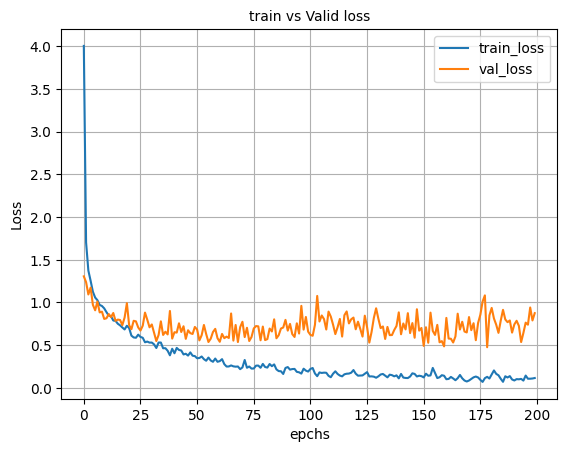

In [43]:
pl_view.plot(rss_hst.history["loss"], label="train_loss")
pl_view.plot(rss_hst.history["val_loss"], label="val_loss")
pl_view.xlabel("epchs")
pl_view.ylabel("Loss")
pl_view.title("train vs Valid loss", fontsize=10)
pl_view.legend()
pl_view.grid()
pl_view.show()

# Evaluation

In [44]:
rsscn_forecast_labels=cvt.predict(x_rsscn_tst)

9/9 [==============================] - 1s 28ms/step


In [45]:
rsscn_forecast_labels= sc_p_op.argmax(rsscn_forecast_labels, axis=1)

In [46]:
from sklearn.metrics import confusion_matrix as rsscn_evamat
rsscn_fcon=rsscn_evamat(y_rsscn_tst,rsscn_forecast_labels)


Text(95.72222222222221, 0.5, 'Truth')

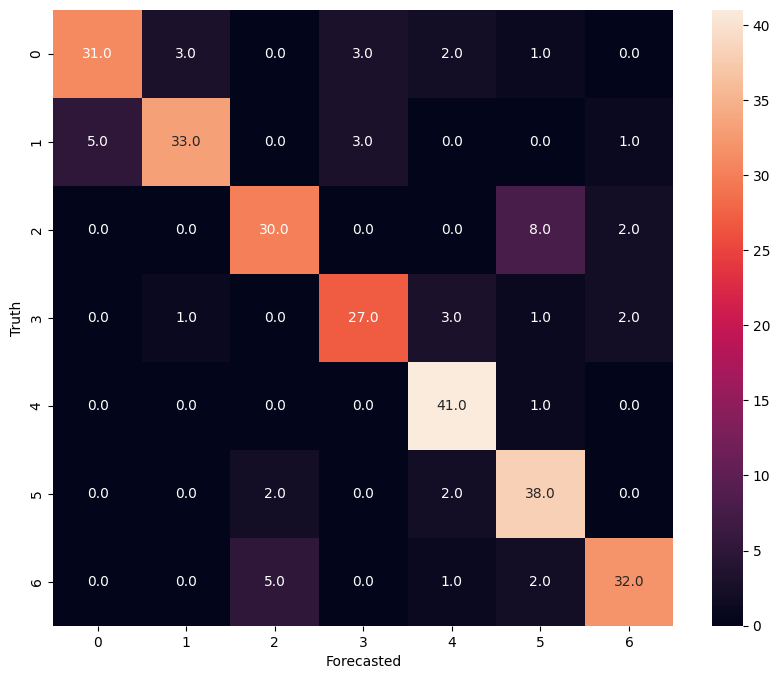

In [47]:
#confusion matrix realization with seaborn
import seaborn as b_s_b
pl_view.figure(figsize=(10,8))
b_s_b.heatmap(rsscn_fcon,annot=True, fmt=".1f")
pl_view.xlabel('Forecasted')
pl_view.ylabel('Truth')

In [48]:
from sklearn.metrics import classification_report as eva_crp

In [49]:
rsscn_cl_nm = ['0-Grass','1-Field','2-Industry','3-River Lake','4-Forest','5-Resident','6-Parking']
print(eva_crp(y_rsscn_tst, rsscn_forecast_labels, target_names=rsscn_cl_nm))

              precision    recall  f1-score   support

     0-Grass       0.86      0.78      0.82        40
     1-Field       0.89      0.79      0.84        42
  2-Industry       0.81      0.75      0.78        40
3-River Lake       0.82      0.79      0.81        34
    4-Forest       0.84      0.98      0.90        42
  5-Resident       0.75      0.90      0.82        42
   6-Parking       0.86      0.80      0.83        40

    accuracy                           0.83       280
   macro avg       0.83      0.83      0.83       280
weighted avg       0.83      0.83      0.83       280

